# Posttest 1 Eksplorasi Dataset Zoo

**Nama:** Dewi Astuti
**Nim:** 2409106007
**Dataset:** Zoo Dataset — UCI Machine Learning Repository  
**Link sumber:** https://archive.ics.uci.edu/dataset/111/zoo

## Tentang Dataset

Dataset yang diguanakan adalah Zoo Dataset, isinya data 101 ekor hewan yang punya 18 atribut/kolom. Dataset ini biasa dipakai untuk latihan klasifikasi, tujuannya nebak `class_type` (kelas taksonomi hewan, 1-7) berdasarkan 16 ciri-ciri lain kayak berambut atau nggak, bertelur atau nggak, punya sirip atau nggak, dan sebagainya.

Kolom-kolomnya:

| Kolom | Tipe Data | Penjelasan |
|---|---|---|
| `animal_name` | object | nama hewan (unik tiap baris) |
| `hair` | int64 (0/1) | berambut? |
| `feathers` | int64 (0/1) | berbulu (unggas)? |
| `eggs` | int64 (0/1) | bertelur? |
| `milk` | int64 (0/1) | menyusui? |
| `airborne` | int64 (0/1) | bisa terbang? |
| `aquatic` | int64 (0/1) | hidup di air? |
| `predator` | int64 (0/1) | predator? |
| `toothed` | int64 (0/1) | punya gigi? |
| `backbone` | int64 (0/1) | punya tulang belakang? |
| `breathes` | int64 (0/1) | bernapas pakai paru-paru? |
| `venomous` | int64 (0/1) | berbisa? |
| `fins` | int64 (0/1) | punya sirip? |
| `legs` | int64 | jumlah kaki, nilainya cuma di {0,2,4,5,6,8} |
| `tail` | int64 (0/1) | punya ekor? |
| `domestic` | int64 (0/1) | hewan peliharaan? |
| `catsize` | int64 (0/1) | ukurannya sebesar kucing ke atas? |
| `class_type` | int64 | kode kelas taksonomi (1-7) |

Karena hampir semua kolomnya cuma berisi 0/1 (boolean), aku tambahin satu kolom bantuan yaitu `class_name` yang isinya nama kelas taksonomi (Mammalia, Aves, Reptilia, dst) hasil mapping dari `class_type`. Tujuannya biar ada contoh atribut object yang punya beberapa label/kategori (kalau cuma `animal_name` doang, semua labelnya unik jadi kurang enak buat dianalisis kayak contoh "Jenis Kelamin" atau "Agama" di soal).


## 1. Import Library

library yang dipakai buat eksplorasi dan visualisasi data adalah **Pandas** (buat baca & olah data), **Matplotlib** (buat bikin grafik dasar seperti bar, histogram, pie, scatter, line, dan boxplot), dan **Seaborn** (buat bikin heatmap korelasi biar lebih gampang dan rapi).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## 2. Membaca Dataset

Data yang digunakan dari file `zoo.csv` pakai `pd.read_csv()`. lalu saya membuat kolom tambahan `class_name` pakai `.map()` buat ubah kode angka `class_type` jadi nama kelas taksonomi yang lebih gampang dibaca.

In [18]:
df = pd.read_csv("zoo.csv")
class_map = {
    1: "Mammalia",
    2: "Aves",
    3: "Reptilia",
    4: "Pisces",
    5: "Amphibia",
    6: "Insecta",
    7: "Invertebrata"
}

df["class_name"] = df["class_type"].map(class_map)
df.head()
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Atribut numerik:")
print(numeric_cols)

Atribut numerik:
['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type']


### **3**. **Statistik Deskriptif Atribut Angka**
Menampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1, Q2, dan Q3 dari attribute bertipe angka.

Karena kebanyakan kolomnya cuma isi 0 dan 1 (boolean), nilai mean-nya bisa dibaca sebagai **persentase hewan yang punya ciri itu**. Misalnya kalau mean `milk` = 0.41, artinya sekitar 41% hewan di dataset ini menyusui.

In [16]:
desc = df[numeric_cols].describe().T

desc = desc.rename(columns={
    "mean": "Rata-rata",
    "std": "Std Dev",
    "min": "Min",
    "25%": "Q1",
    "50%": "Q2 (Median)",
    "75%": "Q3",
    "max": "Max"
})

desc[["Rata-rata", "Std Dev", "Min", "Q1", "Q2 (Median)", "Q3", "Max"]]

,Rata-rata,Std Dev,Min,Q1,Q2 (Median),Q3,Max
hair,0.425743,0.496921,0.0,0.0,0.0,1.0,1.0
feathers,0.198020,0.400495,0.0,0.0,0.0,0.0,1.0
eggs,0.584158,0.495325,0.0,0.0,1.0,1.0,1.0
milk,0.405941,0.493522,0.0,0.0,0.0,1.0,1.0
airborne,0.237624,0.427750,0.0,0.0,0.0,0.0,1.0
aquatic,0.356436,0.481335,0.0,0.0,0.0,1.0,1.0
predator,0.554455,0.499505,0.0,0.0,1.0,1.0,1.0
toothed,0.603960,0.491512,0.0,0.0,1.0,1.0,1.0
backbone,0.821782,0.384605,0.0,1.0,1.0,1.0,1.0
breathes,0.792079,0.407844,0.0,1.0,1.0,1.0,1.0


## 4. 10 Data Pertama (Kolom Angka Saja)

Tampilkan 10 record pertama dari dataset dengan attribute bertipe angka`.head(10)`.

In [ ]:
df[numeric_cols].head(10)


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
5,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
6,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
7,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,4
8,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
9,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1


## 5. Jumlah Label Atribut Object

Tampilkan informasi jumlah record, jumlah attribute, nama attribute, jumlah attribute dengan tipe angka.

- `animal_name` → seharusnya 101 label unik karena tiap hewan namanya beda-beda.
- `class_name` → cuma ada 7 label, sesuai jumlah kelas taksonomi hewan di dataset ini.

In [20]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    print(f"Atribut: {col}")
    print(f"Jumlah label unik: {df[col].nunique()}")
    print(df[col].value_counts())
    print("-" * 40)

Atribut: animal_name
Jumlah label unik: 100
animal_name
frog        2
aardvark    1
bass        1
antelope    1
bear        1
           ..
wallaby     1
wasp        1
wolf        1
worm        1
wren        1
Name: count, Length: 100, dtype: int64
----------------------------------------
Atribut: class_name
Jumlah label unik: 7
class_name
Mammalia        41
Aves            20
Pisces          13
Invertebrata    10
Insecta          8
Reptilia         5
Amphibia         4
Name: count, dtype: int64
----------------------------------------


## 7. Visualisasi Data

Visualisasikan dataset menggunakan dua jenis grafik

### a. Grafik Batang (Bar Chart)

Grafik batang cocok dipakai buat bandingin jumlah data antar kategori. Karena `class_name` itu kategorikal (cuma ada 7 kategori: Mammalia, Aves, dst), aku pakai `plt.bar()` buat lihat berapa banyak hewan di tiap kelas.

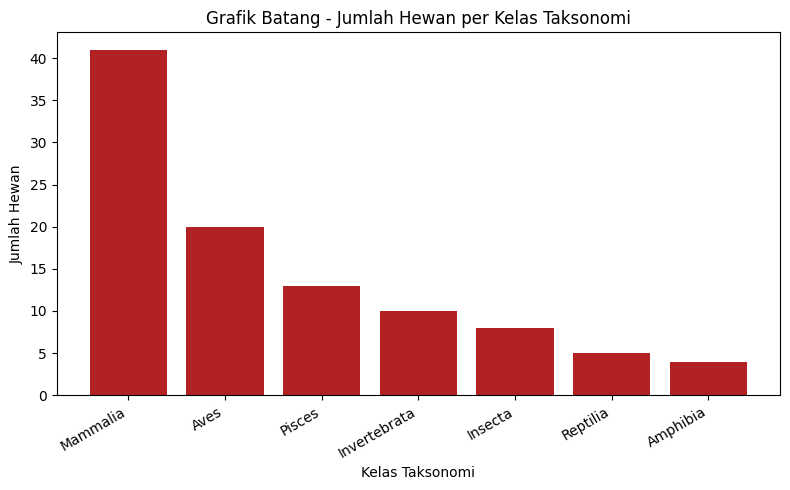

In [21]:
class_counts = df["class_name"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color="firebrick")
plt.title("Grafik Batang - Jumlah Hewan per Kelas Taksonomi")
plt.xlabel("Kelas Taksonomi")
plt.ylabel("Jumlah Hewan")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### b. Grafik Histogram

Histogram cocok buat lihat distribusi/sebaran data numerik, jadi aku pakai buat lihat sebaran jumlah kaki (`legs`) hewan-hewan di dataset ini pakai `plt.hist()`. Kelihatan kalau kebanyakan hewan itu punya 4 kaki atau 0 kaki (kayak ular, ikan).

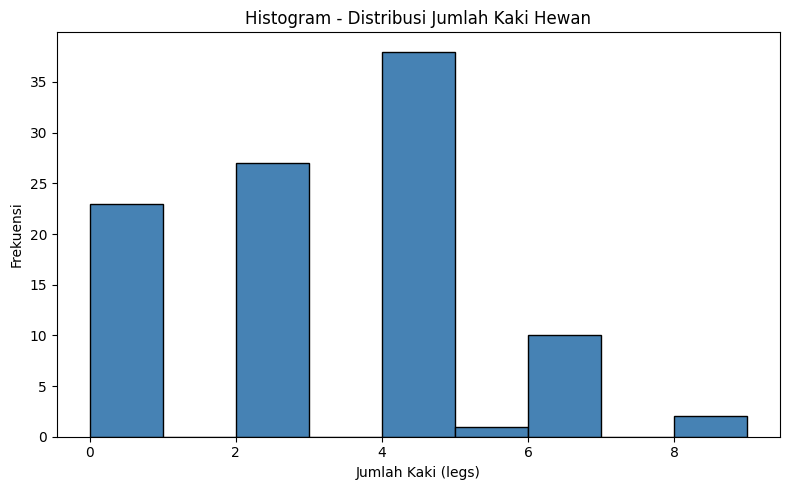

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df["legs"], bins=[0,1,2,3,4,5,6,7,8,9], color="steelblue", edgecolor="black")
plt.title("Histogram - Distribusi Jumlah Kaki Hewan")
plt.xlabel("Jumlah Kaki (legs)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()


### c. Grafik Lingkaran (Pie Chart)

Karena `class_name` itu data kategorikal, aku coba juga lihat proporsinya pakai pie chart (`plt.pie()`). Ini bagus buat lihat persentase tiap kelas dari keseluruhan data, ketimbang cuma lihat jumlahnya doang kayak di bar chart.

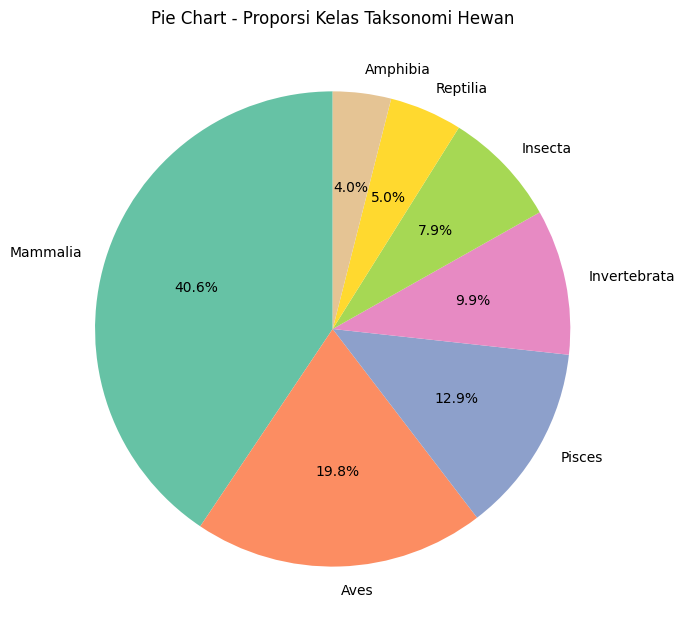

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("Set2"))
plt.title("Pie Chart - Proporsi Kelas Taksonomi Hewan")
plt.tight_layout()
plt.show()


### d. Grafik Kotak (Box Plot)

Aku juga coba boxplot buat lihat sebaran jumlah kaki (`legs`) di tiap kelas taksonomi. Boxplot ini bagus buat lihat median, sebaran data, sama outlier-nya sekaligus. Kelihatan misalnya kelas Insecta lumayan konsisten di 6 kaki, sementara Mammalia sebarannya lebih variatif.

/tmp/ipykernel_85/3073028122.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class_name", y="legs", order=class_counts.index, palette="Set3")


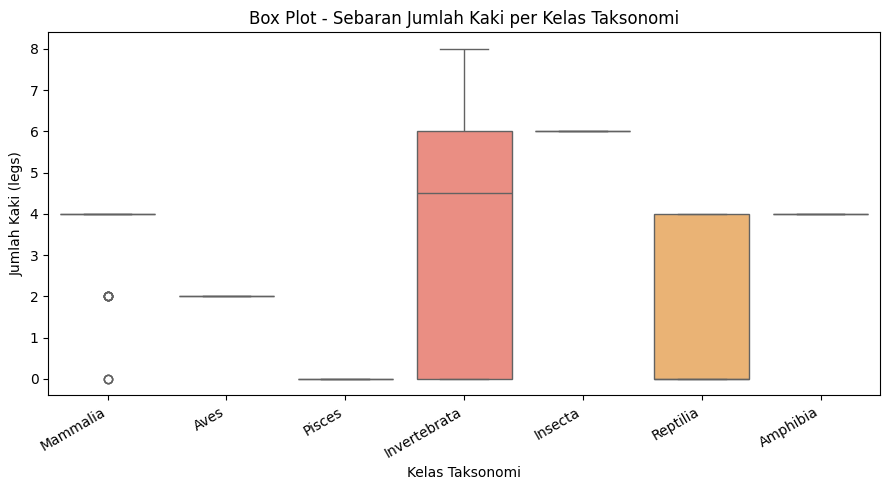

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="class_name", y="legs", order=class_counts.index, palette="Set3")
plt.title("Box Plot - Sebaran Jumlah Kaki per Kelas Taksonomi")
plt.xlabel("Kelas Taksonomi")
plt.ylabel("Jumlah Kaki (legs)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 8. Heatmap Korelasi

Terakhir, sesuai kriteria soal, aku bikin heatmap buat lihat korelasi antar atribut yang tipenya angka. Korelasinya dihitung pakai `.corr()` dulu, baru divisualisasikan pakai `sns.heatmap()` biar kelihatan pola hubungannya — makin merah/gelap warnanya, makin kuat hubungan positifnya, makin biru berarti makin kuat hubungan negatifnya.

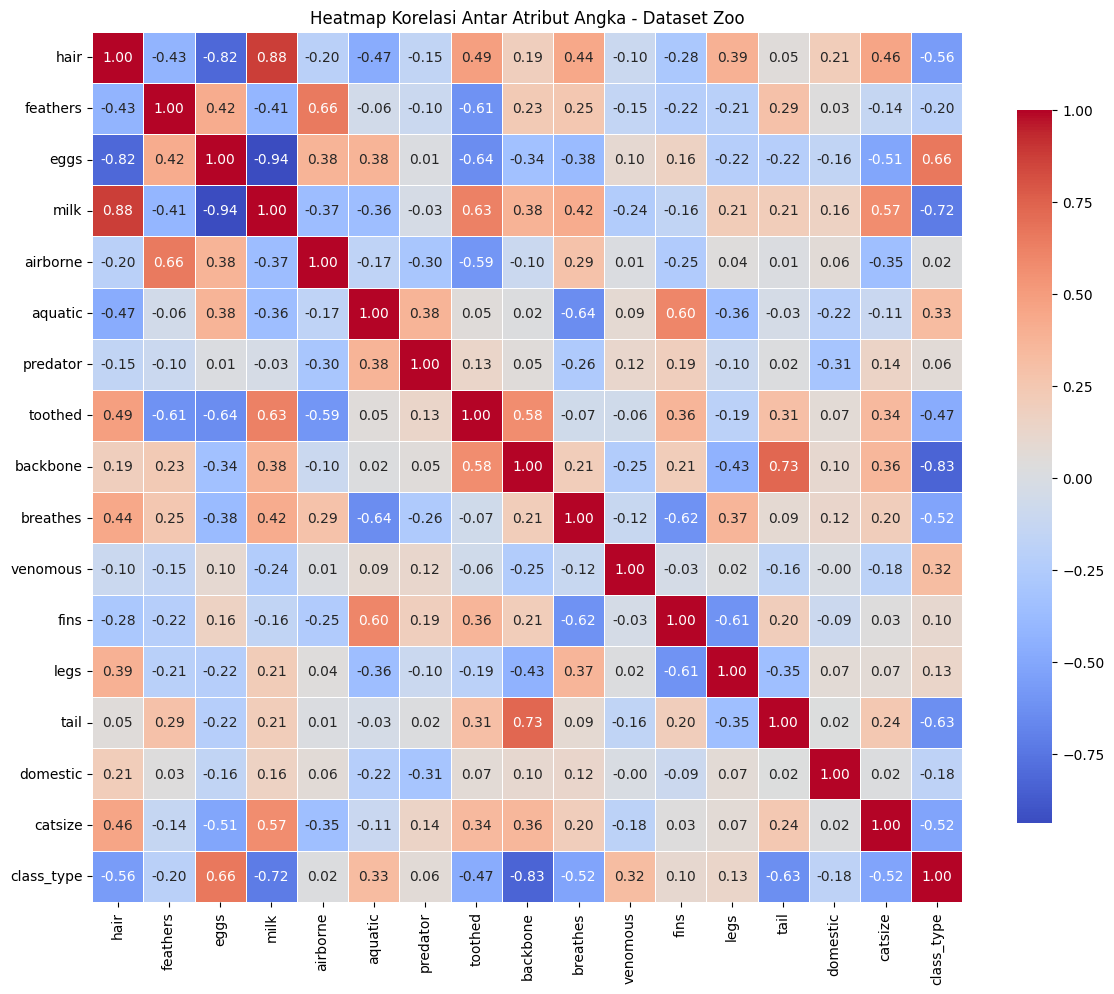

In [ ]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Heatmap Korelasi Antar Atribut Angka - Dataset Zoo")
plt.tight_layout()
plt.show()


## 9. Kesimpulan

Dari eksplorasi yang aku lakukan, bisa disimpulkan:

- Dataset Zoo berisi **101 record** dan **18 atribut asli**, ditambah 1 kolom bantuan `class_name` yang digunakan untuk mempermudah baca kategori kelas hewan.
- tidak ada data yang kosong (missing value) sama sekali di dataset ini.
- Mayoritas atributnya berupa data biner (0/1), kecuali `legs` (jumlah kaki) dan `class_type`/`class_name` (kelas taksonomi).
- Kelas **Mammalia** paling banyak jumlahnya (41 hewan), sedangkan **Amphibia** paling sedikit (cuma 4 hewan).
- Dari heatmap, kelihatan `milk` dan `hair` punya korelasi positif yang kuat — masuk akal karena dua-duanya emang ciri khas mamalia. Sebaliknya `feathers` berkorelasi negatif sama keduanya, karena burung nggak berambut dan nggak menyusui.
